# Mixture of Mixture of Gaussians Example

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex

# Set Parameters

In [13]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = .1

# Generate Data

In [14]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(-2,2,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

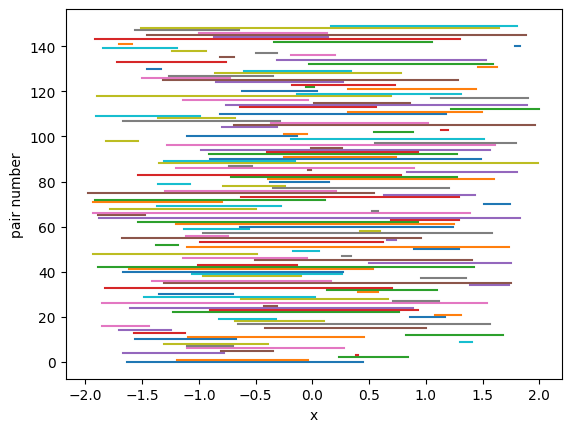

In [15]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

In [16]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = 4*(X[component_ids==0] > 0) # x + 1
Y[(component_ids==1)] = 4*(X[component_ids==1] < 0) #3*x+ 2 #4
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

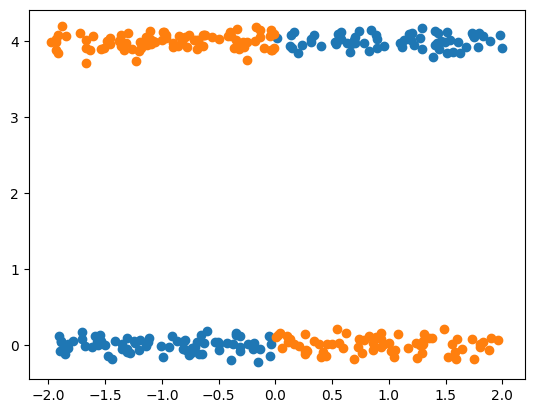

In [17]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [18]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 0.5/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [19]:
kern_width = 0.4

K = gauss_kernal_mat(X,X,sigma=kern_width)
w, A = scipy.sparse.linalg.eigs(K, k=M)
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 25

R = np.zeros((n,M))

for i in range(maxiter):
    print(i)
    # E-step
    Delta = (Y - K@A)**2 #square loss for each observation for each component
    print("detla", np.shape(Delta))
    print("y", np.shape(Y))
    #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
    Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
    R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
    print("R", np.shape(R))
    
    # M-step
    w = np.sum(R,axis=0) / n
    for j in range(M):
        Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        A[:,j] = lstsq_nesterov((K.T*Rm).T, (Y.T*Rm).T, A[:,j])
        #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=None)[0].flatten()
        print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))

0
detla (300, 2)
y (300, 1)
R (150, 2)
final:  25.306459696962207
final:  15.384363583184866
1
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.21925095780644
final:  19.743413895996753
2
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.18376706712121
final:  19.708657002594165
3
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.156276222052668
final:  19.684299010520338
4
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.134105709912014
final:  19.666084961194596
5
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.115882104629186
final:  19.65193260648226
6
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.100713613139323
final:  19.640617696830013
7
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.087977119222817
final:  19.63137759402824
8
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.077215978220764
final:  19.623715198859664
9
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.068082253606033
final:  19.617291010334263
10
detla (300, 2)
y (300, 1)
R (150, 2)
final:  28.060302474759027
final: 

# Check out the results

In [20]:
Y_hat = np.zeros((2*n,M))
for j in range(M):
        #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
        Y_hat[:,j] = K@A[:,j]

Prop Correct Mixture Assignment = 0.5266666666666666


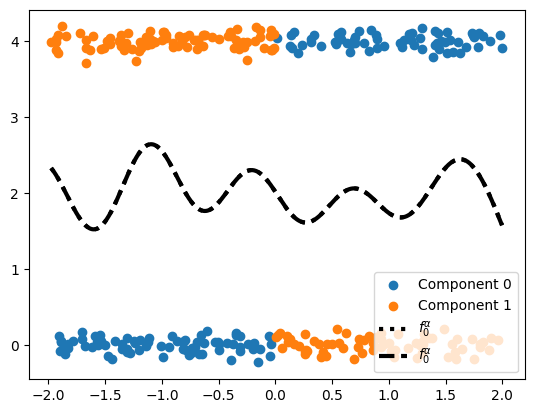

In [24]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(np.min(X),np.max(X),1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

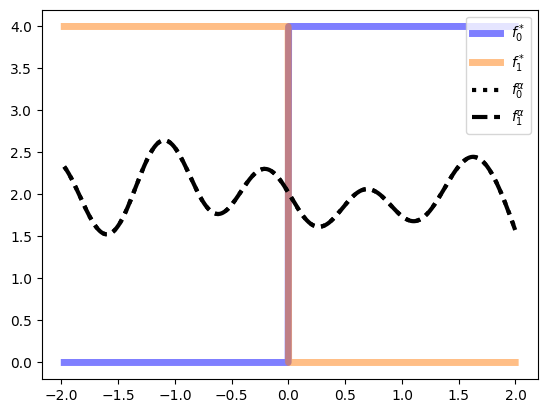

In [22]:
plt.plot(xx, 4*(xx>0), 'b', linewidth=5, label="$f_0^*$", alpha=0.5) #(xx>0) + 1
plt.plot(xx, 4*(xx<0), 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5) #3*(xx<0) + 2
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()
